# Fine-tuning DistilBERT (cahya/distilbert-base-indonesian) untuk Semantic Search
**Pendekatan:** Masked Language Modeling (MLM) — Domain-Adaptive Pretraining

Notebook ini **terpisah** dari notebook utama (`distilbert-cahya.ipynb`) 
Alurnya:
1. Load & preprocessing dataset arsip (sama seperti notebook utama)
2. Menyusun teks dokumen sebagai korpus untuk MLM 
3. Fine-tuning DistilBERT dengan objective Masked Language Modeling (menebak token yang di-*mask*)
4. Simpan model hasil fine-tuning (siap dijadikan Kaggle Dataset/Model)
5. Sanity check: bandingkan cosine similarity intra-category vs inter-category sebelum & sesudah fine-tuning



## 1️. Instalasi & Import Library

In [16]:
# Install library yang dibutuhkan (khusus Kaggle environment)
!pip install -q transformers openpyxl

In [17]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForMaskedLM, DataCollatorForLanguageModeling
from sklearn.model_selection import train_test_split
from IPython.display import display

# Reproducibility
SEED = 7
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print('✅ Semua library berhasil diimport')
print(f'   PyTorch version : {torch.__version__}')
print(f'   Device          : {"GPU" if torch.cuda.is_available() else "CPU"}')


✅ Semua library berhasil diimport
   PyTorch version : 2.10.0+cu128
   Device          : GPU


## 2️. Load Dataset

In [18]:
# ── Sesuaikan path dengan lokasi file di Kaggle (samakan dengan notebook utama) ──
FILE_PATH = '/kaggle/input/datasets/muhammadhaekal74/arsip-unida-metadata/dataset_arsip.xlsx'

df = pd.read_excel(FILE_PATH)

print(f'✅ Dataset berhasil dimuat')
print(f'   Jumlah baris   : {len(df):,}')
print(f'   Jumlah kolom   : {len(df.columns)}')
display(df[['title', 'description', 'keywords', 'categoryId']].head(3))


✅ Dataset berhasil dimuat
   Jumlah baris   : 784
   Jumlah kolom   : 18


,title,description,keywords,categoryId
0,Pengangkatan tim Perumus Visi dan Misi Univers...,Dokumen ini berisi tentang amanat Rektor perih...,"SK, Rektor, pengangkatan, tim perumus, visi da...",3
1,Visi dan Misi Universitas Darussalam Gontor,Dokumen ini berisi tentang Visi dan Misi Unive...,"SK, Keputusan, Rektor, Visi dan Misi, UNIDA",3
2,Penetapan Struktur Fungsionaris Centre For Isl...,Dokumen ini berisi tentang nama - nama yang di...,"SK, Rektor, Fungsionaris, CIES, UNIDA",3


## 3️. Preprocessing (identik dengan notebook utama)

In [19]:
def clean_text(text: str) -> str:
    """Bersihkan teks: lowercase, hapus karakter khusus, normalisasi spasi."""
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def build_combined_text(row: pd.Series) -> str:
    """Gabungkan kolom title + description + keywords menjadi satu teks."""
    parts = [
        clean_text(str(row.get('title', ''))),
        clean_text(str(row.get('description', ''))),
        clean_text(str(row.get('keywords', '')))
    ]
    return ' '.join(p for p in parts if p)


df['combined_text'] = df.apply(build_combined_text, axis=1)
df = df[df['combined_text'].str.strip() != ''].reset_index(drop=True)

print('✅ Preprocessing selesai')
print(f'   Dokumen valid  : {len(df):,}')
print()
print('Distribusi categoryId:')
display(df['categoryId'].value_counts().sort_index())


✅ Preprocessing selesai
   Dokumen valid  : 784

Distribusi categoryId:


categoryId
1     77
3    324
4     19
5     57
6     75
7     25
8    207
Name: count, dtype: int64

## 4️. Split Dataset untuk Training MLM

Berbeda dengan pendekatan *contrastive learning* yang membutuhkan pasangan (anchor, positive)
dari `categoryId`, pendekatan MLM **tidak memerlukan label sama sekali** — cukup teks dokumen
itu sendiri sebagai korpus pelatihan. `categoryId` tetap dipertahankan pada split data
(`stratify`) semata-mata agar proporsi kategori pada data train/val tetap representatif,
bukan karena dibutuhkan oleh objective MLM.


In [20]:
VAL_SIZE = 0.15  # porsi dokumen untuk validasi

train_df, val_df = train_test_split(
    df, test_size=VAL_SIZE, stratify=df['categoryId'], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f'✅ Split dokumen: {len(train_df)} train, {len(val_df)} val')
print()
print('Contoh combined_text (train):')
print(train_df['combined_text'].iloc[0])


✅ Split dokumen: 666 train, 118 val

Contoh combined_text (train):
sop layanan pengajuan surat menyurat sop pengajuan surat menyurat mengatur prosedur permintaan pembuatan surat resmi mulai dari pengajuan kebutuhan verifikasi data penyusunan draft persetujuan pejabat terkait hingga penerbitan surat agar layanan administrasi berjalan tertib cepat dan akurat sop layanan pengajuan surat menyurat


## 5️. Load Model Dasar (Base Model) untuk MLM

In [21]:
MODEL_NAME  = 'cahya/distilbert-base-indonesian'
MAX_LENGTH  = 256
BATCH_SIZE  = 16
EPOCHS      = 15
LR          = 2e-5
MLM_PROB    = 0.15   # proporsi token yang di-mask, standar BERT/RoBERTa

print(f'🔄 Memuat model dasar "{MODEL_NAME}" ke {DEVICE.upper()}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# AutoModelForMaskedLM: base encoder DistilBERT + head prediksi token (vocab projector)
model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME).to(DEVICE)

print('✅ Model dasar (dengan MLM head) berhasil dimuat')


🔄 Memuat model dasar "cahya/distilbert-base-indonesian" ke CUDA...


Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie distilbert.embeddings.word_embeddings.weight to vocab_projector.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Model dasar (dengan MLM head) berhasil dimuat


## 6️. Mean Pooling & Fungsi Encoding untuk Sanity Check

Fungsi ini dipakai khusus untuk mengambil representasi *embedding* dokumen (bukan logit prediksi
token), dengan mengambil *hidden state* terakhir dari base encoder — MLM head (`vocab_projector`)
tidak dipakai di sini, karena tujuannya murni untuk mengukur kualitas representasi vektor,
sama seperti pada pendekatan *contrastive learning* sebelumnya.


In [22]:
def mean_pooling_from_hidden(hidden_states, attention_mask):
    """Mean Pooling dari hidden state terakhir (bukan logit MLM)."""
    mask_expanded  = attention_mask.unsqueeze(-1).float()
    sum_embeddings = (hidden_states * mask_expanded).sum(1)
    sum_mask       = mask_expanded.sum(1).clamp(min=1e-9)
    return sum_embeddings / sum_mask


@torch.no_grad()
def encode_texts_eval(texts, batch_size=BATCH_SIZE):
    """Encode tanpa gradient — dipakai untuk sanity check sebelum/sesudah fine-tuning."""
    model.eval()
    all_embeddings = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True,
                             max_length=MAX_LENGTH, return_tensors='pt').to(DEVICE)
        output = model(**encoded, output_hidden_states=True)
        # hidden_states[-1] == last_hidden_state dari base encoder (setara AutoModel biasa)
        last_hidden = output.hidden_states[-1]
        emb = mean_pooling_from_hidden(last_hidden, encoded['attention_mask'])
        emb = F.normalize(emb, p=2, dim=1)
        all_embeddings.append(emb.cpu().numpy())
    return np.vstack(all_embeddings).astype(np.float32)


print('✅ Fungsi mean_pooling_from_hidden & encode_texts_eval siap')


✅ Fungsi mean_pooling_from_hidden & encode_texts_eval siap


## 6.1 Sanity Check — Sebelum Fine-tuning

In [23]:
def intra_inter_similarity(df, n_per_cat=15, n_cats=2, seed=SEED):
    rng = random.Random(seed)
    cats = df['categoryId'].value_counts()
    cats = cats[cats >= n_per_cat].index.tolist()
    chosen_cats = rng.sample(cats, min(n_cats, len(cats)))

    sample_df = pd.concat([
        df[df['categoryId'] == c].sample(n=n_per_cat, random_state=seed)
        for c in chosen_cats
    ]).reset_index(drop=True)

    embeddings = encode_texts_eval(sample_df['combined_text'].tolist())
    sim_matrix = embeddings @ embeddings.T
    cats_arr = sample_df['categoryId'].values

    intra_sims, inter_sims = [], []
    n = len(sample_df)
    for i in range(n):
        for j in range(i + 1, n):
            if cats_arr[i] == cats_arr[j]:
                intra_sims.append(sim_matrix[i, j])
            else:
                inter_sims.append(sim_matrix[i, j])

    return np.mean(intra_sims), np.mean(inter_sims), chosen_cats


intra_before, inter_before, chosen_cats = intra_inter_similarity(df)
print('===== SEBELUM FINE-TUNING (MLM) =====')
print(f'   Kategori sampel        : {chosen_cats}')
print(f'   Rata-rata sim intra    : {intra_before:.4f}')
print(f'   Rata-rata sim inter    : {inter_before:.4f}')
print(f'   Selisih (intra-inter)  : {intra_before - inter_before:.4f}')


===== SEBELUM FINE-TUNING (MLM) =====
   Kategori sampel        : [1, 8]
   Rata-rata sim intra    : 0.8173
   Rata-rata sim inter    : 0.7203
   Selisih (intra-inter)  : 0.0971


## 7️. Dataset & DataCollator untuk Training MLM

`DataCollatorForLanguageModeling` dari HuggingFace menangani dua hal otomatis di setiap batch:
1. **Dynamic padding** — menyamakan panjang token dalam satu batch
2. **Random masking** — menyembunyikan `MLM_PROB` (15%) token secara acak, lalu membuat
   `labels` (token asli sebelum di-*mask*, hanya pada posisi yang di-*mask*)


In [24]:
class TextDataset(Dataset):
    """Dataset sederhana: tokenisasi teks tanpa padding (padding ditangani collator)."""
    def __init__(self, texts, tokenizer, max_length=MAX_LENGTH):
        self.encodings = tokenizer(texts, truncation=True, max_length=max_length)

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}


data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=True, mlm_probability=MLM_PROB
)

train_dataset = TextDataset(train_df['combined_text'].tolist(), tokenizer)
val_dataset   = TextDataset(val_df['combined_text'].tolist(), tokenizer)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=data_collator, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=data_collator, drop_last=True
)

print(f'✅ DataLoader siap — {len(train_loader)} batch train, {len(val_loader)} batch val '
      f'(batch_size={BATCH_SIZE}, mlm_probability={MLM_PROB})')


✅ DataLoader siap — 41 batch train, 7 batch val (batch_size=16, mlm_probability=0.15)


## 8️. Training — Masked Language Modeling

Untuk setiap batch:
1. `data_collator` men-*mask* ±15% token secara acak dan menyediakan `labels`
2. Model memprediksi token asli pada posisi yang di-*mask* (`vocab_projector` head)
3. Loss = *cross-entropy* antara token prediksi dan token asli, dihitung otomatis oleh
   `AutoModelForMaskedLM` dan dikembalikan lewat `outputs.loss`




In [25]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
loss_history = []
val_loss_history = []

for epoch in range(EPOCHS):
    # ── Training ──────────────────────────────────────────────
    model.train()
    epoch_losses = []

    for batch in train_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer.zero_grad()
        outputs = model(**batch)   # outputs.loss = MLM cross-entropy loss
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    avg_loss = float(np.mean(epoch_losses))
    loss_history.append(avg_loss)

    # ── Validation ────────────────────────────────────────────
    model.eval()
    epoch_val_losses = []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            epoch_val_losses.append(outputs.loss.item())

    avg_val_loss = float(np.mean(epoch_val_losses))
    val_loss_history.append(avg_val_loss)

    print(f'Epoch {epoch+1:>2}/{EPOCHS} — Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

print()
print('✅ Fine-tuning (MLM) selesai')


Epoch  1/15 — Train Loss: 2.1232 | Val Loss: 1.7165
Epoch  2/15 — Train Loss: 1.7611 | Val Loss: 1.6237
Epoch  3/15 — Train Loss: 1.6421 | Val Loss: 1.4291
Epoch  4/15 — Train Loss: 1.5411 | Val Loss: 1.3016
Epoch  5/15 — Train Loss: 1.3233 | Val Loss: 1.3734
Epoch  6/15 — Train Loss: 1.3707 | Val Loss: 1.1687
Epoch  7/15 — Train Loss: 1.2729 | Val Loss: 1.2802
Epoch  8/15 — Train Loss: 1.2452 | Val Loss: 1.1835
Epoch  9/15 — Train Loss: 1.1885 | Val Loss: 1.1147
Epoch 10/15 — Train Loss: 1.1984 | Val Loss: 1.4242
Epoch 11/15 — Train Loss: 1.1311 | Val Loss: 1.0086
Epoch 12/15 — Train Loss: 1.0958 | Val Loss: 1.0666
Epoch 13/15 — Train Loss: 1.0251 | Val Loss: 1.1141
Epoch 14/15 — Train Loss: 1.0461 | Val Loss: 1.1018
Epoch 15/15 — Train Loss: 0.9744 | Val Loss: 1.0655

✅ Fine-tuning (MLM) selesai


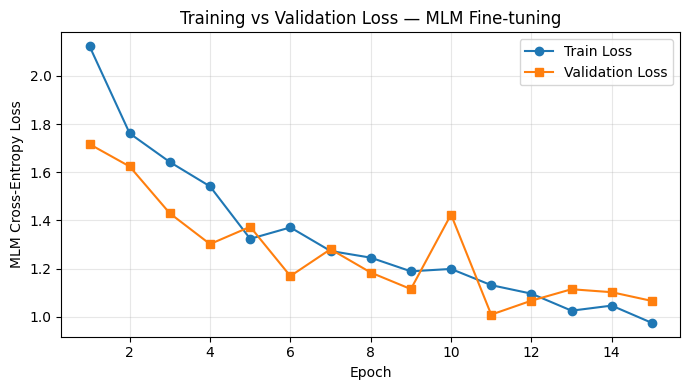

In [26]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), loss_history, marker='o', label='Train Loss')
plt.plot(range(1, EPOCHS + 1), val_loss_history, marker='s', label='Validation Loss')
plt.title('Training vs Validation Loss — MLM Fine-tuning')
plt.xlabel('Epoch')
plt.ylabel('MLM Cross-Entropy Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss_curve_mlm.png', dpi=150)
plt.show()


## 9️. Sanity Check — Sesudah Fine-tuning

In [27]:
intra_after, inter_after, _ = intra_inter_similarity(df, seed=SEED)

comparison = pd.DataFrame({
    'Metrik': ['Rata-rata sim intra-category', 'Rata-rata sim inter-category', 'Selisih (intra - inter)'],
    'Sebelum Fine-tuning': [f'{intra_before:.4f}', f'{inter_before:.4f}', f'{intra_before - inter_before:.4f}'],
    'Sesudah Fine-tuning': [f'{intra_after:.4f}', f'{inter_after:.4f}', f'{intra_after - inter_after:.4f}'],
})
display(comparison)

print()
if (intra_after - inter_after) > (intra_before - inter_before):
    print('✅ Fine-tuning (MLM) meningkatkan separasi antar kategori (indikasi awal positif).')
else:
    print(' Separasi belum meningkat — wajar untuk MLM karena tidak ada sinyal categoryId')
    print('   selama pelatihan; MLM hanya memperkaya pemahaman bahasa domain arsip secara umum,')
    print('   bukan menata representasi berdasarkan kategori seperti contrastive learning.')


,Metrik,Sebelum Fine-tuning,Sesudah Fine-tuning
0,Rata-rata sim intra-category,0.8173,0.7835
1,Rata-rata sim inter-category,0.7203,0.6653
2,Selisih (intra - inter),0.0971,0.1182



✅ Fine-tuning (MLM) meningkatkan separasi antar kategori (indikasi awal positif).


## 9.1 Eksperimen Multi-Seed — Validasi Stabilitas Training

Mengulang **seluruh proses training dari awal** (model dasar fresh) untuk 5 seed berbeda:
`[42, 123, 2024, 7, 99]`. Tujuannya sama seperti pada notebook *contrastive learning*
sebelumnya — membuktikan hasil fine-tuning tidak kebetulan bagus di satu seed saja, dan
menghasilkan **Mean ± Std** dari `final_loss` dan `separation_gap` sebagai bukti
reproducibility metodologis.

> Sel ini menjalankan training 5× penuh (5× lebih lama dari training tunggal). Model dasar
> di-*load* ulang fresh di setiap seed — bukan melanjutkan dari model yang sudah di-fine-tune
> sebelumnya.


In [28]:
# ══════════════════════════════════════════════════════════════════
# EKSPERIMEN MULTI-SEED — Training Ulang dari Awal untuk 5 Seed (MLM)
# ══════════════════════════════════════════════════════════════════
SEEDS = [42, 123, 2024, 7, 99]

multiseed_results = []

for exp_seed in SEEDS:
    print('=' * 60)
    print(f'🔁 Training MLM dengan SEED = {exp_seed}')
    print('=' * 60)

    torch.manual_seed(exp_seed)
    np.random.seed(exp_seed)
    random.seed(exp_seed)

    # ── Split dengan seed ini ─────────────────────────────────────
    exp_train_df, exp_val_df = train_test_split(
        df, test_size=VAL_SIZE, stratify=df['categoryId'], random_state=exp_seed
    )

    exp_train_dataset = TextDataset(exp_train_df['combined_text'].tolist(), tokenizer)
    exp_val_dataset   = TextDataset(exp_val_df['combined_text'].tolist(), tokenizer)

    exp_train_loader = DataLoader(
        exp_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        collate_fn=data_collator, drop_last=True
    )
    exp_val_loader = DataLoader(
        exp_val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        collate_fn=data_collator, drop_last=True
    )

    # ── Model dasar fresh (reset dari pretrained, bukan lanjutan) ─
    exp_model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME).to(DEVICE)
    exp_optimizer = torch.optim.AdamW(exp_model.parameters(), lr=LR, weight_decay=0.01)

    exp_train_loss_history, exp_val_loss_history = [], []

    for epoch in range(EPOCHS):
        exp_model.train()
        epoch_losses = []
        for batch in exp_train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            exp_optimizer.zero_grad()
            loss = exp_model(**batch).loss
            loss.backward()
            exp_optimizer.step()
            epoch_losses.append(loss.item())
        exp_train_loss_history.append(float(np.mean(epoch_losses)))

        exp_model.eval()
        epoch_val_losses = []
        with torch.no_grad():
            for batch in exp_val_loader:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                epoch_val_losses.append(exp_model(**batch).loss.item())
        exp_val_loss_history.append(float(np.mean(epoch_val_losses)))

    final_train_loss = exp_train_loss_history[-1]
    final_val_loss    = exp_val_loss_history[-1]

    # ── Sanity check pakai model hasil seed ini ───────────────────
    global model
    _orig_model = model
    model = exp_model  # sementara dialihkan supaya encode_texts_eval pakai exp_model
    exp_intra, exp_inter, _ = intra_inter_similarity(df, seed=SEED)
    model = _orig_model  # kembalikan

    exp_gap = exp_intra - exp_inter

    multiseed_results.append({
        'seed': exp_seed,
        'final_train_loss': final_train_loss,
        'final_val_loss': final_val_loss,
        'intra_category_sim': exp_intra,
        'inter_category_sim': exp_inter,
        'separation_gap': exp_gap,
    })

    print(f'   Final Train Loss : {final_train_loss:.4f}')
    print(f'   Final Val Loss   : {final_val_loss:.4f}')
    print(f'   Separation Gap   : {exp_gap:.4f}')
    print()

    del exp_model
    torch.cuda.empty_cache()

multiseed_df = pd.DataFrame(multiseed_results)

print('=' * 60)
print(' RINGKASAN EKSPERIMEN MULTI-SEED (TRAINING MLM)')
print('=' * 60)
display(multiseed_df)
print()
print(f"Final Train Loss : {multiseed_df['final_train_loss'].mean():.4f} ± {multiseed_df['final_train_loss'].std():.4f}")
print(f"Final Val Loss    : {multiseed_df['final_val_loss'].mean():.4f} ± {multiseed_df['final_val_loss'].std():.4f}")
print(f"Separation Gap    : {multiseed_df['separation_gap'].mean():.4f} ± {multiseed_df['separation_gap'].std():.4f}")


🔁 Training MLM dengan SEED = 42


Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie distilbert.embeddings.word_embeddings.weight to vocab_projector.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


   Final Train Loss : 0.9936
   Final Val Loss   : 1.2232
   Separation Gap   : 0.1253

🔁 Training MLM dengan SEED = 123


Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie distilbert.embeddings.word_embeddings.weight to vocab_projector.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


   Final Train Loss : 0.9141
   Final Val Loss   : 1.1505
   Separation Gap   : 0.1188

 RINGKASAN EKSPERIMEN MULTI-SEED (TRAINING MLM)


,seed,final_train_loss,final_val_loss,intra_category_sim,inter_category_sim,separation_gap
0,42,0.993559,1.223204,0.783671,0.658357,0.125314
1,123,0.927045,1.212829,0.785559,0.666567,0.118992
2,2024,0.941335,1.293487,0.782210,0.661512,0.120698
3,7,0.974381,1.065527,0.783515,0.665278,0.118236
4,99,0.914083,1.150548,0.771492,0.652677,0.118815



Final Train Loss : 0.9501 ± 0.0331
Final Val Loss    : 1.1891 ± 0.0857
Separation Gap    : 0.1204 ± 0.0029


## 9.2 Langkah Selanjutnya — Training Model Produksi

Setelah melihat `multiseed_df` di atas:

1. Pilih seed terbaik (default rekomendasi: `final_val_loss` terendah — bisa juga pilih yang
   `separation_gap`-nya paling dekat ke rata-rata, untuk representasi yang lebih fair).
2. Ubah `SEED = 7` di **cell konfigurasi awal** (bagian Import Library) menjadi seed terpilih.
3. Jalankan ulang notebook ini **dari cell awal sampai bagian Simpan Model** (bagian 10) —
   proses training tunggal yang sudah ada di notebook ini akan otomatis memakai seed terpilih
   tersebut sebagai model produksi final.




## 10. Simpan Model Hasil Fine-tuning




In [29]:
SAVE_DIR = './distilbert-arsip-finetuned-mlm'

model.base_model.save_pretrained(SAVE_DIR)   # hanya base encoder, tanpa MLM head
tokenizer.save_pretrained(SAVE_DIR)

print(f'✅ Model & tokenizer tersimpan di: {SAVE_DIR}')
print()


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model & tokenizer tersimpan di: ./distilbert-arsip-finetuned-mlm



In [30]:
import shutil
from IPython.display import FileLink

# Zip folder model
shutil.make_archive('distilbert-arsip-finetuned-mlm', 'zip', SAVE_DIR)

# Buat link download
FileLink('distilbert-arsip-finetuned-mlm.zip')


/kaggle/working/distilbert-arsip-finetuned-mlm.zip